# Delta features by visit to Delta Fatigue

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher, PatientDataType
from src.model import DMOLSTM
from src.core.enums import MileStone
from src.core.data_transforms import Transform
from src.train import TrainRegression
from torchmetrics.regression import R2Score

import matplotlib.pyplot as plt

import numpy as np
import torch


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
dmo_features = [
    "cadence_30_p90_d",
    "cadence_30_avg_d",
    "ws_30_p90_d",
    "strlen_1030_avg_d",
    "cadence_all_avg_d",
]

In [4]:
pdd = PatientDataDispatcher("config/config.yaml", dmo_features, MileStone.ALL)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [5]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [6]:
from src.model import lstm_regression
config = lstm_regression
config.notes = "None"

In [7]:
def format_input_data_delta_visit(input_data):
    if len(input_data.shape) < 4:
            input_data = input_data.unsqueeze(dim=0)

    patients, visits, days, features = input_data.shape

    delta_visits = torch.zeros(patients, visits - 1, days, features)
    for patient in range(patients):
        reference_visit = input_data[patient, 0]
        for visit in range(visits - 1):
            updated_visit = input_data[patient, visit + 1] - reference_visit
            delta_visits[patient, visit] = updated_visit 

    input_data = delta_visits.reshape(patients * (visits - 1), days, features)
    return input_data
    # return delta_visits

def format_label_data_delta_visit(label_data):
    patients, visits, labels = label_data.shape
    
    delta_labels = torch.zeros(patients, (visits - 1), labels)
    for patient in range(patients):
        reference_label = label_data[patient, 0]
        delta_visits = label_data[patient, 1:] - reference_label

        delta_labels[patient] = delta_visits

    label_data = delta_labels.reshape(patients * (visits - 1), labels)
    return label_data
    # return delta_labels


In [8]:
predicted_values = []
actual_values = []

n_patients, n_visit, n_day, n_features = dmo_data.shape
for patient_index in range(n_patients):
    print(f"X Validation {patient_index}")

    # split data
    train_indexes = [i for i in range(n_patients) if i != patient_index]
    train_data = dmo_data[train_indexes].squeeze(dim=0)
    train_label = dmo_labels[train_indexes]

    test_data = dmo_data[patient_index]
    test_label = dmo_labels[patient_index].unsqueeze(dim=0)

    transform = Transform()

    # fit and transform scaler on training data only, then transform testing
    train_data = transform.fit_transform_dmo_data(train_data)
    test_data = transform.transform_dmo_data(test_data)

    # fit and transform scaler on training labels, then transform testing labels
    train_label = transform.fit_transform_dmo_labels(train_label)
    test_label = transform.transform_dmo_labels(test_label)

    # convert to tensors
    train_data = torch.from_numpy(train_data)
    train_label = torch.from_numpy(train_label)

    test_data = torch.from_numpy(test_data)
    test_label = torch.from_numpy(test_label)

    # format data
    train_data = format_input_data_delta_visit(train_data)
    test_data = format_input_data_delta_visit(test_data)

    train_label = format_label_data_delta_visit(train_label)
    test_label = format_label_data_delta_visit(test_label)

    # Convert to dataloaders
    training_dataloader = Transform.data_to_dataloaders(
        train_data, train_label, batch_size=16
    )
    testing_dataloader = Transform.data_to_dataloaders(
        test_data, test_label, batch_size=16
    )

    # reinstantiate model every loop for x validation
    model = DMOLSTM(config).to(device=device)
    optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

    trainer = TrainRegression(
        model,
        optimiser,
        config,
        training_dataloader,
        testing_dataloader,
        device,
        verbose=True,
    )

    trainer.train_loop(label_transform=lambda x: x.squeeze(dim=0))
    prediction, actual = trainer.test_loop(label_transform=lambda x: x.squeeze(dim=0))

    predicted_values += prediction
    actual_values += actual



X Validation 0
Testing loss: 0.0034830886870622635
X Validation 1
Testing loss: 0.004531466402113438
X Validation 2
Testing loss: 0.11690427362918854
X Validation 3
Testing loss: 0.0017745384247973561
X Validation 4
Testing loss: 0.01703624054789543
X Validation 5
Testing loss: 0.0010090579744428396
X Validation 6
Testing loss: 0.017553456127643585
X Validation 7
Testing loss: 0.0021283053793013096
X Validation 8
Testing loss: 0.02574353851377964
X Validation 9
Testing loss: 0.006280576344579458
X Validation 10
Testing loss: 0.019428402185440063
X Validation 11
Testing loss: 0.00586820300668478
X Validation 12
Testing loss: 0.006186910904943943
X Validation 13
Testing loss: 0.022094516083598137
X Validation 14
Testing loss: 0.020910369232296944
X Validation 15
Testing loss: 0.0026760816108435392
X Validation 16
Testing loss: 0.013974720612168312
X Validation 17
Testing loss: 0.009513599798083305
X Validation 18
Testing loss: 0.01357347797602415
X Validation 19
Testing loss: 0.007162825

In [11]:
print(actual_values)
print(predicted_values)

tensor([-0.0595,  0.0833,  0.5119,  0.0000,  0.0000, -0.0476,  0.1429,  0.0714,
        -0.1667,  0.0595, -0.1786,  0.0476,  0.0952, -0.1429, -0.1071,  0.0119,
         0.1071, -0.0476, -0.1429, -0.0833,  0.0714, -0.1667,  0.5238,  0.3095,
        -0.0714, -0.1548, -0.0238,  0.0357,  0.2143,  0.0119, -0.0238, -0.0833,
         0.0476,  0.0357, -0.3875,  0.0119, -0.1310,  0.0119,  0.0714, -0.0357,
        -0.1190, -0.1905,  0.0357, -0.0833, -0.1548,  0.2738, -0.1429,  0.1429,
         0.0476, -0.0476,  0.1190,  0.0952, -0.0238,  0.0476, -0.0119,  0.0000,
        -0.0714, -0.0952, -0.0595, -0.0833,  0.0833,  0.0476,  0.2024, -0.2024,
        -0.0952,  0.2024, -0.1786, -0.0119,  0.1190,  0.0357, -0.1548, -0.1071,
        -0.0833, -0.0357, -0.1190,  0.1667, -0.0714,  0.0000,  0.0000,  0.0119,
        -0.0476, -0.0357, -0.2381,  0.0357, -0.2262,  0.1786])
tensor([-2.7435e-04, -2.8318e-04, -9.0791e-04, -2.6372e-05, -3.0761e-04,
        -1.0930e-03, -2.7780e-04,  1.7312e-02, -2.1172e-04, -2.6

All metrics: {'accuracy': 0.5930232558139535, 'Mean Squared Error': 0.02088339813053608, 'Mean Absolute Error': 0.10554258525371552, 'R^2': -0.004006743431091309}


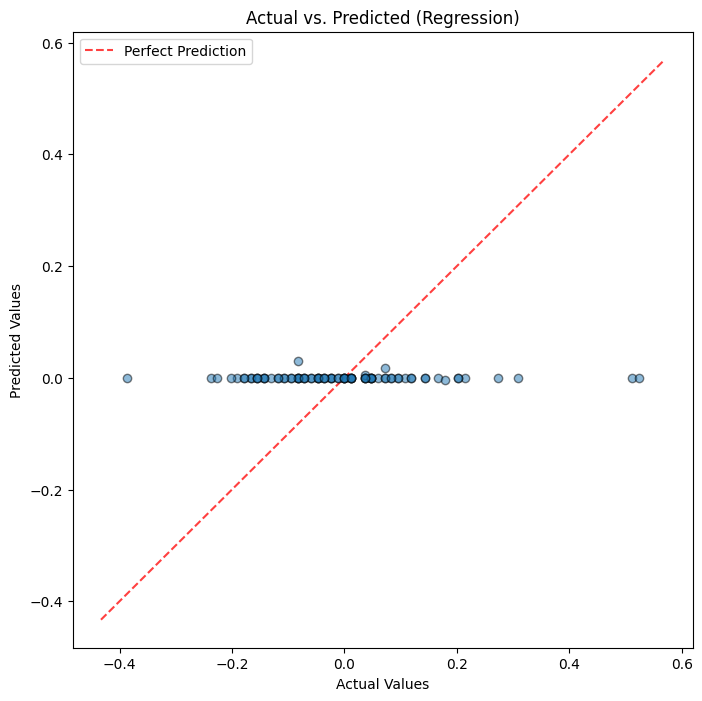

In [12]:
from src.evaluation import Evaluation
import matplotlib.pyplot as plt

actual_values = torch.Tensor(actual_values)
predicted_values = torch.Tensor(predicted_values)

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
